In [1]:
import boto3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

BUCKET_NAME = "dsan6000-yh973"
PREFIX = "wikipedia-hourly/"

s3 = boto3.client("s3", region_name="us-east-1")

In [2]:
response = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix=PREFIX)
keys = sorted(obj["Key"] for obj in response["Contents"] if obj["Key"].endswith(".parquet"))
print(f"Found {len(keys)} parquet files in s3://{BUCKET_NAME}/{PREFIX}")

Found 24 parquet files in s3://dsan6000-yh973/wikipedia-hourly/


In [3]:
hourly_dfs = []
for key in keys:
    hour_df = pd.read_parquet(f"s3://{BUCKET_NAME}/{key}")
    hourly_dfs.append(hour_df)
    print(f"Loaded s3://{BUCKET_NAME}/{key}: {len(hour_df):,} events")

df = pd.concat(hourly_dfs, ignore_index=True)
df["hour"] = pd.to_datetime(df["file_ts_str"], format="%Y%m%d_%H%M%S")
print(f"Combined DataFrame: {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded s3://dsan6000-yh973/wikipedia-hourly/20260901_040000.parquet: 4,458 events
Loaded s3://dsan6000-yh973/wikipedia-hourly/20260901_050000.parquet: 3,769 events
Loaded s3://dsan6000-yh973/wikipedia-hourly/20260901_060000.parquet: 3,981 events
Loaded s3://dsan6000-yh973/wikipedia-hourly/20260901_070000.parquet: 3,186 events
Loaded s3://dsan6000-yh973/wikipedia-hourly/20260901_080000.parquet: 3,519 events
Loaded s3://dsan6000-yh973/wikipedia-hourly/20260901_090000.parquet: 3,316 events
Loaded s3://dsan6000-yh973/wikipedia-hourly/20260901_100000.parquet: 3,654 events
Loaded s3://dsan6000-yh973/wikipedia-hourly/20260901_110000.parquet: 4,056 events
Loaded s3://dsan6000-yh973/wikipedia-hourly/20260901_120000.parquet: 4,599 events
Loaded s3://dsan6000-yh973/wikipedia-hourly/20260901_130000.parquet: 6,200 events
Loaded s3://dsan6000-yh973/wikipedia-hourly/20260901_140000.parquet: 6,023 events
Loaded s3://dsan6000-yh973/wikipedia-hourly/20260901_150000.parquet: 5,465 events
Loaded s3://dsan

In [4]:
hourly_counts = df.groupby("hour").size().reset_index(name="num_events")
type_counts = df.groupby(["hour", "type"]).size().reset_index(name="num_events")
hourly_counts.head()

,hour,num_events
0,2026-09-01 04:00:00,4458
1,2026-09-01 05:00:00,3769
2,2026-09-01 06:00:00,3981
3,2026-09-01 07:00:00,3186
4,2026-09-01 08:00:00,3519


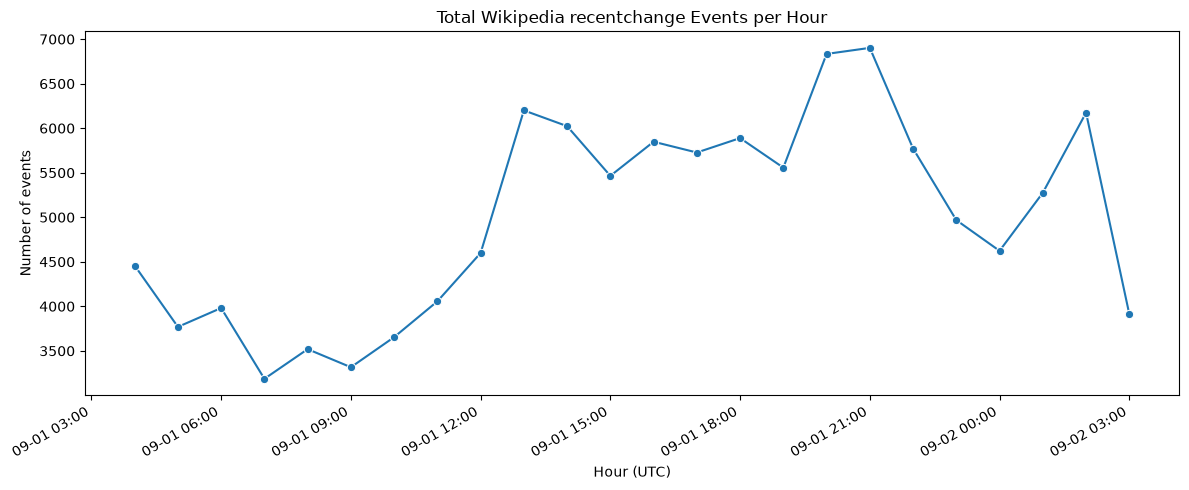

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=hourly_counts, x="hour", y="num_events", marker="o", ax=ax)
ax.set_title("Total Wikipedia recentchange Events per Hour")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Number of events")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("images/hourly-events.png", dpi=150)
fig.savefig("images/hourly-events.svg")
plt.show()

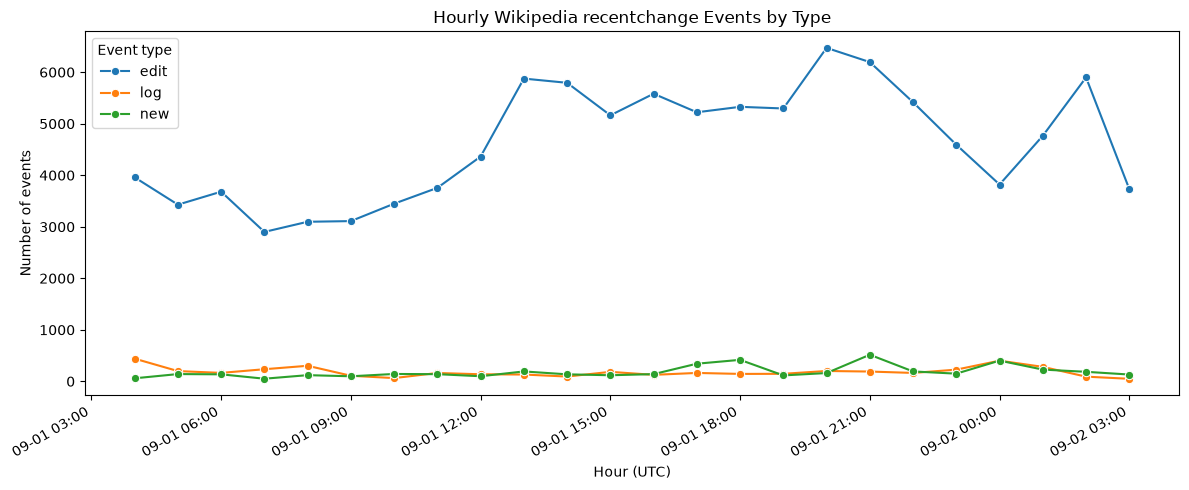

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=type_counts, x="hour", y="num_events", hue="type", marker="o", ax=ax)
ax.set_title("Hourly Wikipedia recentchange Events by Type")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Number of events")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
ax.legend(title="Event type")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("images/events-by-type.png", dpi=150)
fig.savefig("images/events-by-type.svg")
plt.show()